In [40]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from matplotlib import pyplot as plt
from matplotlib_inline import backend_inline
from d2l import d2l_torch as d2l

def use_svg_display():              #@save
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')

### 3.5.1 读取数据集

In [9]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数形式
# 并除以255使得所有像素的数值均为0~1
import os

trans = transforms.ToTensor()
data_path = "../data/FashionMNIST/raw"

# FashionMNIST数据集的关键文件
required_train_files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz"
]

required_test_files = [
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

# 检查所有必需文件是否存在
train_files_exist = all(
    os.path.exists(os.path.join(data_path, f)) for f in required_train_files
)

if train_files_exist:
    print("训练数据集已存在，直接读取...")
    download_train_needed = False
else:
    print("训练数据集不存在或不完整，正在下载...")
    download_train_needed = True

test_files_exist = all(
    os.path.exists(os.path.join(data_path, f)) for f in required_test_files
)

if train_files_exist:
    print("测试数据集已存在，直接读取...")
    download_test_needed = False
else:
    print("测试数据集不存在或不完整，正在下载...")
    download_test_needed = True

mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=download_train_needed
)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=download_test_needed
)

训练数据集已存在，直接读取...
测试数据集已存在，直接读取...


In [10]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [16]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [18]:
mnist_train.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [19]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

In [23]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # 图像张量
            ax.imshow(img.numpy())
        else:
            # PIL图像
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

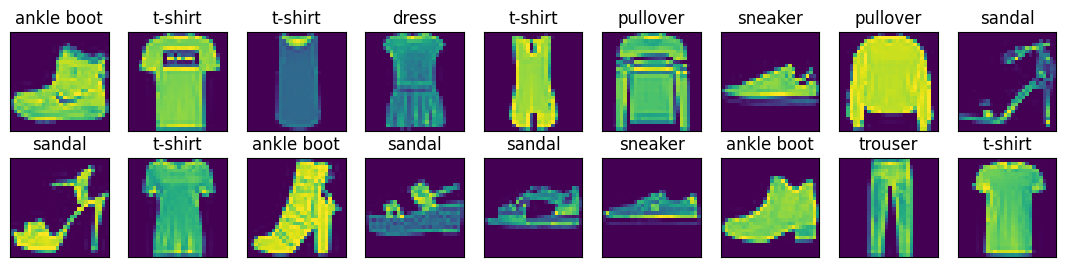

In [25]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18, num_workers=0)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

### 3.5.2 读取小批量

In [31]:
batch_size = 256

def get_dataloader_workers():
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers())

In [41]:
timer = d2l.Timer()

for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'5.34 sec'

### 3.5.3 整合所有组件

In [45]:
def load_data_fashion_mnist(batch_size, resize=None):
    import os
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)

    data_path = "../data/FashionMNIST/raw"

    # FashionMNIST数据集的关键文件
    required_train_files = [
        "train-images-idx3-ubyte.gz",
        "train-labels-idx1-ubyte.gz"
    ]

    required_test_files = [
        "t10k-images-idx3-ubyte.gz",
        "t10k-labels-idx1-ubyte.gz"
    ]

    # 检查所有必需文件是否存在
    train_files_exist = all(
        os.path.exists(os.path.join(data_path, f)) for f in required_train_files
    )

    if train_files_exist:
        print("训练数据集已存在，直接读取...")
        download_train_needed = False
    else:
        print("训练数据集不存在或不完整，正在下载...")
        download_train_needed = True

    test_files_exist = all(
        os.path.exists(os.path.join(data_path, f)) for f in required_test_files
    )

    if test_files_exist:
        print("测试数据集已存在，直接读取...")
        download_test_needed = False
    else:
        print("测试数据集不存在或不完整，正在下载...")
        download_test_needed = True

    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=download_train_needed
    )
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=download_test_needed
    )

    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=get_dataloader_workers()))

In [46]:
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

训练数据集已存在，直接读取...
测试数据集已存在，直接读取...
torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64
